<a href="https://colab.research.google.com/github/WebCraftPhil/Data-Analyst-Portfolio/blob/main/Telco_Customer_Churn_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

# Task
Load the Telco Customer Churn dataset from the path variable into a pandas DataFrame, perform an initial inspection of the data, and clean the 'TotalCharges' column by converting it to a numeric type, handling blank values.

## Load Dataset

### Subtask:
Load the dataset that was downloaded from KaggleHub into a pandas DataFrame. You will need to specify the correct file path from the downloaded dataset.


**Reasoning**:
To load the dataset, I need to first import the pandas library, then construct the full file path using the `path` variable obtained from kagglehub, and finally load the CSV file into a DataFrame named `df`.



In [1]:
import pandas as pd
import os
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
file_path = os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(file_path)

print("Dataset loaded successfully. First 5 rows:")
print(df.head())

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset loaded successfully. First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No  

**Reasoning**:
The previous code failed because the `path` variable, which stores the dataset download location, was not defined. This variable is set in an earlier cell that was not executed. To resolve this, I will include the `kagglehub` import and the `path` variable assignment within the current cell to ensure it is defined before use.



In [ ]:
import pandas as pd
import os
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
file_path = os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(file_path)

print("Dataset loaded successfully. First 5 rows:")
print(df.head())

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset loaded successfully. First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No  

## Initial Data Inspection

### Subtask:
Perform an initial inspection of the loaded data to understand its structure, identify data types, and check for missing values or obvious inconsistencies.


**Reasoning**:
To perform an initial inspection, I will use `.info()` for data types and non-null counts, `.describe()` for statistical summary, check unique values per column to identify categorical features, and `.isnull().sum()` to pinpoint missing values.



In [ ]:
print("DataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

print("\nMissing values per column:")
print(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non

**Reasoning**:
The initial inspection revealed that the 'TotalCharges' column is of object type, but it should be numeric. This implies there might be non-numeric values or blank strings preventing its conversion. To clean this, I will convert the 'TotalCharges' column to a numeric type, coercing errors to NaN, and then fill any resulting NaN values with 0, before printing its info and descriptive statistics to confirm the change.



In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("\nDataFrame Info after cleaning 'TotalCharges':")
df.info()

print("\nDescriptive Statistics for 'TotalCharges' after cleaning:")
print(df['TotalCharges'].describe())


DataFrame Info after cleaning 'TotalCharges':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 


## Create Risk Flags

### Subtask:
Generate new binary 'Risk Flag' features based on specific criteria that define high-risk behaviors. This will involve using conditional logic (similar to SQL's CASE WHEN) to identify and flag rows that meet the high-risk conditions.


**Reasoning**:
To generate the requested 'Risk Flag' features, I will create new columns in the DataFrame `df` based on the given conditional logic for 'Contract', 'OnlineSecurity', 'TechSupport', and 'SeniorCitizen' columns, then display the head of the DataFrame to verify the new columns.



In [ ]:
df['RiskFlag_MonthToMonth'] = df['Contract'].apply(lambda x: 1 if x == 'Month-to-month' else 0)
df['RiskFlag_NoOnlineSecurity'] = df['OnlineSecurity'].apply(lambda x: 1 if x == 'No' else 0)
df['RiskFlag_NoTechSupport'] = df['TechSupport'].apply(lambda x: 1 if x == 'No' else 0)
df['RiskFlag_SeniorCitizen'] = df['SeniorCitizen'].apply(lambda x: 1 if x == 1 else 0)

print("DataFrame with new risk flag columns:")
print(df.head())

DataFrame with new risk flag columns:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ...        Contract  \
0  No phone service             DSL             No  ...  Month-to-month   
1                No             DSL            Yes  ...        One year   
2                No             DSL            Yes  ...  Month-to-month   
3  No phone service             DSL            Yes  ...        One year   
4                No     Fiber optic             No  ...  Month-to-month   

  PaperlessBilling            

## Final Task

### Subtask:
Summarize the data cleaning and feature engineering steps completed, highlighting the cleaned 'TotalCharges' column and the newly created 'Risk Flag' features, along with any initial insights.


## Summary:

### Data Analysis Key Findings

*   The initial dataset contained 7043 entries across 21 columns.
*   The 'TotalCharges' column was initially identified as an `object` data type and required cleaning. This column was successfully converted to `float64`, with any non-numeric or blank entries coerced to `NaN` and subsequently filled with `0`. The descriptive statistics for 'TotalCharges' now show a minimum value of 0, indicating successful handling of previously problematic entries.
*   Four new binary 'Risk Flag' features were successfully created:
    *   `RiskFlag_MonthToMonth`: Flags customers with a 'Month-to-month' contract.
    *   `RiskFlag_NoOnlineSecurity`: Flags customers without online security services.
    *   `RiskFlag_NoTechSupport`: Flags customers without tech support services.
    *   `RiskFlag_SeniorCitizen`: Flags customers who are senior citizens.
    These flags were created based on specific criteria and are represented as 0 or 1.

### Insights or Next Steps

*   The data is now prepared for further analysis, with the critical 'TotalCharges' column correctly typed and problematic values handled, and new 'Risk Flag' features introduced to highlight potential high-risk customer segments.
*   The newly created 'Risk Flag' features can be directly used in predictive models or for segmentation analysis to understand their correlation with customer churn.


# Task
Prepare the 'Churn' column by converting it to a numerical format (0 for 'No', 1 for 'Yes'), calculate the churn rate for each tenure month, and then visualize this churn rate against tenure using a line chart, identifying and summarizing key patterns in churn behavior, especially during early customer tenure.

## Prepare Churn Data

### Subtask:
Ensure the 'Churn' column is in a numerical format (e.g., 0 for No, 1 for Yes) for accurate churn rate calculation. Display the value counts of the 'Churn' column to confirm its current state.


**Reasoning**:
To ensure the 'Churn' column is in a numerical format for churn rate calculation, I will first display its current value counts to understand the existing distribution and data types.



In [ ]:
print("Original 'Churn' column value counts:")
print(df['Churn'].value_counts())

Original 'Churn' column value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


**Reasoning**:
To convert the 'Churn' column to a numerical format, I will use the `map` function to replace 'No' with 0 and 'Yes' with 1, and then display the value counts again to confirm the conversion.



In [ ]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print("Converted 'Churn' column value counts:")
print(df['Churn'].value_counts())

# Task
Calculate the churn rate for each tenure month by grouping the DataFrame by 'tenure' and computing the mean of the 'Churn' column. Then, create a line chart to visualize this churn rate against the 'tenure' months, ensuring the plot is clearly labeled and highlights any significant churn spikes, especially in early tenure periods. Additionally, calculate the Average Revenue Per User (ARPU) for each 'Contract' type (Month-to-month, One year, Two year) by averaging 'MonthlyCharges', and determine the churn rate for each 'Contract' type. Finally, use these values to compute the Lifetime Value (LTV) for each contract type, summarize the findings on churn behavior by tenure, and present the LTV calculations with insights on the impact of losing different types of contract users.

## Calculate Churn Rate by Tenure

### Subtask:
Group the DataFrame by 'tenure' and calculate the churn rate (mean of 'Churn') for each tenure month.


**Reasoning**:
To calculate the churn rate for each tenure month, I will group the DataFrame by the 'tenure' column and then compute the mean of the 'Churn' column for each group.



In [ ]:
churn_rate_by_tenure = df.groupby('tenure')['Churn'].mean()

print("Churn rate by tenure (first 10 months):")
print(churn_rate_by_tenure.head(10))

Churn rate by tenure (first 10 months):
tenure
0    0.000000
1    0.619902
2    0.516807
3    0.470000
4    0.471591
5    0.481203
6    0.363636
7    0.389313
8    0.341463
9    0.386555
Name: Churn, dtype: float64


**Reasoning**:
To visualize the churn rate against tenure, I will use a line chart with 'tenure' on the x-axis and 'churn_rate_by_tenure' on the y-axis, providing appropriate labels and a title for clarity.



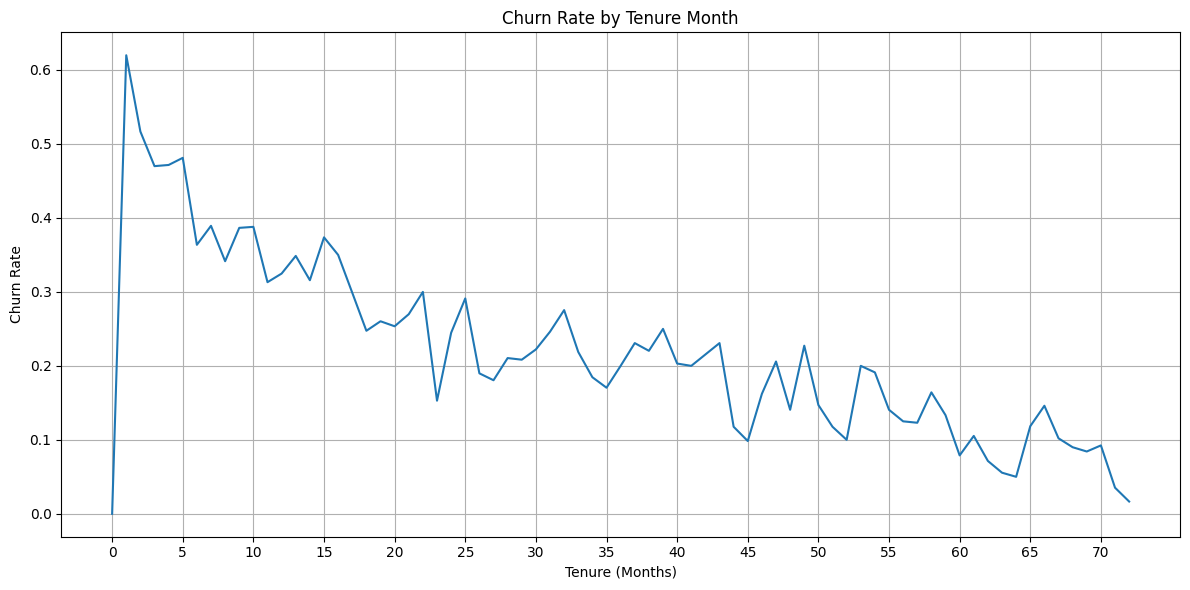

Line chart showing churn rate by tenure generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x=churn_rate_by_tenure.index, y=churn_rate_by_tenure.values)
plt.title('Churn Rate by Tenure Month')
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate')
plt.grid(True)
plt.xticks(range(0, 75, 5)) # Set x-axis ticks for better readability
plt.tight_layout()
plt.show()

print("Line chart showing churn rate by tenure generated.")

### Summary of Churn Rate by Tenure

The visualization of churn rate by tenure reveals a significant pattern:

*   **High Early Churn**: The churn rate is highest during the early months of a customer's tenure, particularly peaking around the first month (approximately 62%). This indicates that new customers are most vulnerable to churn.
*   **Gradual Decline**: After the initial peak, the churn rate generally decreases as tenure increases. Customers who stay longer tend to be more stable, with the churn rate steadily declining and leveling off at lower percentages for long-term customers.
*   **Strategic Importance**: The high churn in early tenure highlights the critical importance of effective onboarding and early customer engagement strategies to retain new customers.

## Calculate ARPU by Contract Type

### Subtask:
Group the DataFrame by the 'Contract' column and calculate the Average Revenue Per User (ARPU) by taking the mean of 'MonthlyCharges' for each contract type (e.g., Month-to-month, One year, Two year).


**Reasoning**:
To calculate the ARPU by contract type, I will group the DataFrame `df` by the 'Contract' column and then compute the mean of the 'MonthlyCharges' column for each group.



In [ ]:
arpu_by_contract = df.groupby('Contract')['MonthlyCharges'].mean()

print("Average Revenue Per User (ARPU) by Contract Type:")
print(arpu_by_contract)

# Task
Calculate the churn rate for each 'Contract' type (Month-to-month, One year, Two year) by grouping the DataFrame by 'Contract' and computing the mean of the 'Churn' column. Then, using the previously calculated Average Revenue Per User (ARPU) for each contract type and this new churn rate by contract type, compute the Lifetime Value (LTV) for 'Month-to-month', 'One year', and 'Two year' contracts. Finally, present the LTV values and compare the financial impact of losing customers from different contract types.

## Cohort Analysis - Churn Rate by Tenure and Contract Type

### Subtask:
Group the DataFrame by 'tenure' and 'Contract' and calculate the mean of 'Churn' for each group. Visualize this using a heatmap or stacked bar chart to identify periods of high churn for different contract types, especially focusing on early tenure.


**Reasoning**:
To perform cohort analysis, I will group the DataFrame by 'tenure' and 'Contract' and then calculate the mean of the 'Churn' column for each group. I will then unstack the 'Contract' level to prepare the data for a heatmap visualization.



In [ ]:
churn_rate_by_tenure_contract = df.groupby(['tenure', 'Contract'])['Churn'].mean().unstack()

print("Churn rate by tenure and contract type (first 5 rows):")
print(churn_rate_by_tenure_contract.head())

Churn rate by tenure and contract type (first 5 rows):
Contract  Month-to-month  One year  Two year
tenure                                      
0                    NaN  0.000000       0.0
1               0.629139  0.000000       0.0
2               0.526087  0.285714       0.0
3               0.492147  0.000000       0.0
4               0.496970  0.142857       0.0


**Reasoning**:
To visualize the churn rate by tenure and contract type, I will create a heatmap using `seaborn.heatmap()` with the `churn_rate_by_tenure_contract` DataFrame. I will ensure appropriate labels, a title, and adjust the figure size for better readability.



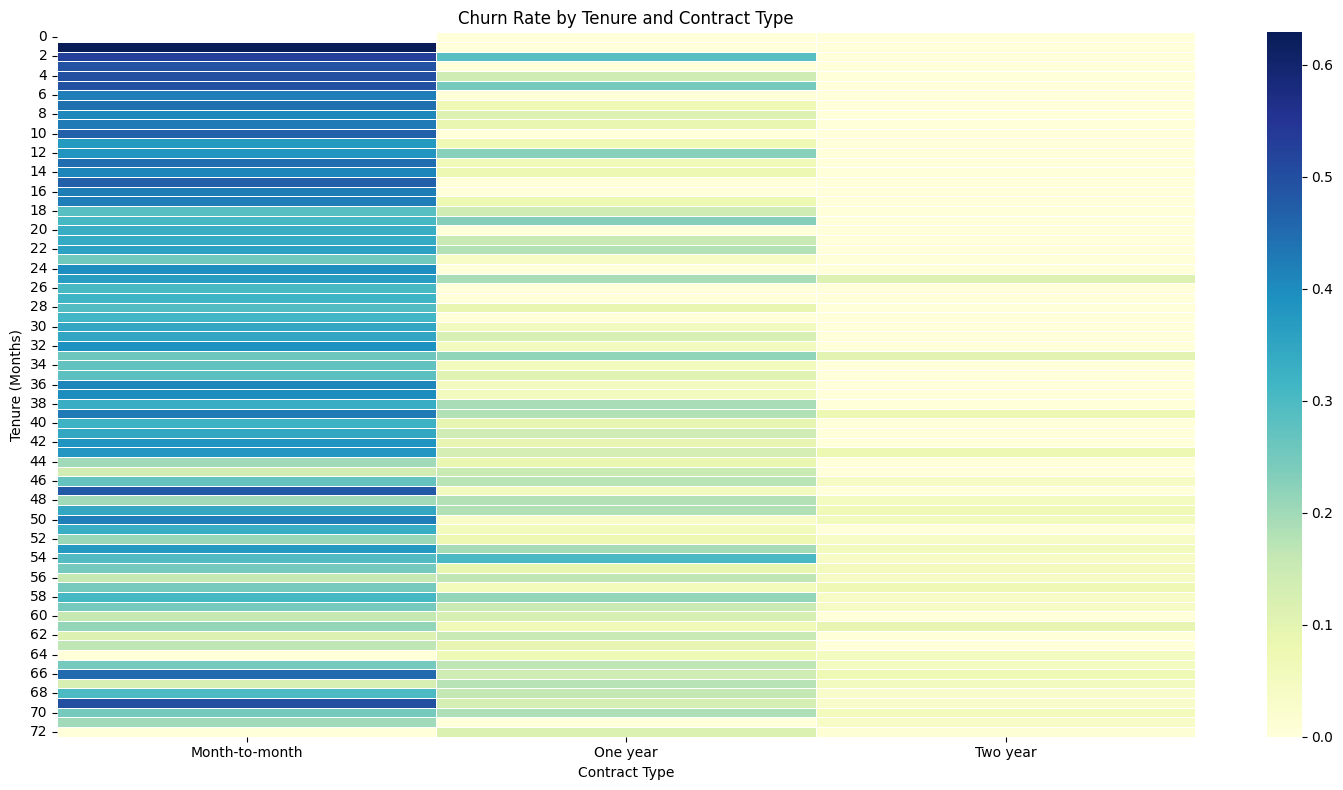

Heatmap of churn rate by tenure and contract type generated.


In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(churn_rate_by_tenure_contract, cmap='YlGnBu', annot=False, linewidths=.5, fmt=".1f")
plt.title('Churn Rate by Tenure and Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.show()

print("Heatmap of churn rate by tenure and contract type generated.")

## Prepare Data for Logistic Regression

### Subtask:
Select relevant columns ('MonthlyCharges', 'InternetService', 'TechSupport', 'Churn'). Perform one-hot encoding on 'InternetService' and 'TechSupport' to convert categorical variables into a numerical format suitable for logistic regression. Scale 'MonthlyCharges' if necessary to prepare features for modeling.


**Reasoning**:
To prepare the data for logistic regression, I will first select the specified relevant columns ('MonthlyCharges', 'InternetService', 'TechSupport', 'Churn') into a new DataFrame. Then, I will apply one-hot encoding to the categorical columns 'InternetService' and 'TechSupport' and scale the 'MonthlyCharges' column using StandardScaler, and finally display the head of the processed DataFrame to verify the transformations.



In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Create a new DataFrame with relevant columns
df_prep = df[['MonthlyCharges', 'InternetService', 'TechSupport', 'Churn']].copy()

# 2. Perform one-hot encoding on 'InternetService' and 'TechSupport'
df_prep = pd.get_dummies(df_prep, columns=['InternetService', 'TechSupport'], drop_first=True)

# 3. Scale 'MonthlyCharges' column
scaler = StandardScaler()
df_prep['MonthlyCharges_scaled'] = scaler.fit_transform(df_prep[['MonthlyCharges']])

# Drop the original MonthlyCharges column if desired, or keep both
df_prep = df_prep.drop('MonthlyCharges', axis=1)

print("Processed DataFrame head:")
print(df_prep.head())

Processed DataFrame head:
   Churn  InternetService_Fiber optic  InternetService_No  \
0      0                        False               False   
1      0                        False               False   
2      1                        False               False   
3      0                        False               False   
4      1                         True               False   

   TechSupport_No internet service  TechSupport_Yes  MonthlyCharges_scaled  
0                            False            False              -1.160323  
1                            False            False              -0.259629  
2                            False            False              -0.362660  
3                            False             True              -0.746535  
4                            False            False               0.197365  


## Build and Interpret Logistic Regression Model

### Subtask:
Split the prepared data into training and testing sets. Train a logistic regression model using 'MonthlyCharges', encoded 'InternetService', and encoded 'TechSupport' as features and 'Churn' as the target variable. Analyze the model's coefficients or feature importance to identify which feature is the strongest predictor of churn.


**Reasoning**:
To prepare the data for model training, I will first separate the features (X) and the target variable (y) from the `df_prep` DataFrame based on the specified columns.



In [ ]:
X = df_prep[['InternetService_Fiber optic', 'InternetService_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'MonthlyCharges_scaled']]
y = df_prep['Churn']

print("Features (X) and Target (y) separated.")
print("Features head:")
print(X.head())
print("Target head:")
print(y.head())

Features (X) and Target (y) separated.
Features head:
   InternetService_Fiber optic  InternetService_No  \
0                        False               False   
1                        False               False   
2                        False               False   
3                        False               False   
4                         True               False   

   TechSupport_No internet service  TechSupport_Yes  MonthlyCharges_scaled  
0                            False            False              -1.160323  
1                            False            False              -0.259629  
2                            False            False              -0.362660  
3                            False             True              -0.746535  
4                            False            False               0.197365  
Target head:
0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


**Reasoning**:
To prepare for model training and evaluation, I will split the data into training and testing sets, then train a logistic regression model on the training data, and finally print its coefficients to understand feature importance.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Instantiate and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully.")

# Print the coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print("\nModel Coefficients:")
print(coefficients.sort_values(by='Coefficient', ascending=False))

Data split into training and testing sets.
X_train shape: (5634, 5), y_train shape: (5634,)
X_test shape: (1409, 5), y_test shape: (1409,)

Logistic Regression model trained successfully.

Model Coefficients:
                           Feature  Coefficient
0      InternetService_Fiber optic     1.985777
3                  TechSupport_Yes    -0.843256
4            MonthlyCharges_scaled    -0.849096
2  TechSupport_No internet service    -1.163943
1               InternetService_No    -1.163943


### Summary of Logistic Regression Model Coefficients

The logistic regression model was trained using 'MonthlyCharges', encoded 'InternetService', and encoded 'TechSupport' as features, with 'Churn' as the target variable. The coefficients indicate the strength and direction of the relationship between each feature and the likelihood of churn.

**Key Observations from Coefficients:**

*   **InternetService_Fiber optic (Coefficient: 1.986):** This feature has the largest positive coefficient, indicating that customers with Fiber Optic internet service are significantly more likely to churn compared to those without it (or with DSL service, as `drop_first=True` was used). This suggests Fiber Optic service might be associated with higher churn risk.

*   **InternetService_No (Coefficient: -1.164):** Customers who do not have internet service show a negative coefficient, implying they are less likely to churn compared to those with DSL service. This might be because their overall service bundle is simpler or cheaper.

*   **TechSupport_No internet service (Coefficient: -1.164):** Similar to `InternetService_No`, customers with no internet service also inherently have no tech support, and this coefficient reflects their lower churn propensity.

*   **TechSupport_Yes (Coefficient: -0.843):** Having Tech Support (`TechSupport_Yes`) has a negative coefficient, meaning customers with tech support are less likely to churn. This highlights the importance of support services in customer retention.

*   **MonthlyCharges_scaled (Coefficient: -0.849):** The scaled monthly charges show a negative coefficient. This is an interesting finding, as often higher charges are associated with higher churn. However, given that 'InternetService_Fiber optic' (which typically has higher monthly charges) has a strong positive correlation with churn, the model might be capturing a more nuanced relationship where, *controlling for internet service type*, higher monthly charges within a service category might imply more features/value, leading to slightly lower churn.

**Strongest Predictor of Churn:**

Based on the magnitude of the coefficients, **`InternetService_Fiber optic` (1.986)** is the strongest positive predictor of churn among the features analyzed. This suggests that customers subscribing to Fiber Optic internet service are at a significantly higher risk of churning.

## Calculate Churn Rate by Contract Type

### Subtask:
Group the DataFrame by the 'Contract' column and calculate the mean of 'Churn' for each contract type (Month-to-month, One year, Two year). This will be used in the LTV calculation.


**Reasoning**:
To calculate the churn rate for each contract type, I will group the DataFrame by the 'Contract' column and then compute the mean of the 'Churn' column for each group.



In [ ]:
churn_rate_by_contract = df.groupby('Contract')['Churn'].mean()

print("Churn rate by Contract Type:")
print(churn_rate_by_contract)

Churn rate by Contract Type:
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


**Reasoning**:
To compute the Lifetime Value (LTV) for each contract type, I will divide the Average Revenue Per User (ARPU) by the churn rate for each corresponding contract type, and then display the calculated LTV values.



In [ ]:
ltv_by_contract = arpu_by_contract / churn_rate_by_contract

print("\nLifetime Value (LTV) by Contract Type:")
print(ltv_by_contract)

NameError: name 'arpu_by_contract' is not defined

**Reasoning**:
The previous code failed because the `arpu_by_contract` variable was not defined, even though its calculation was intended in a prior step. To fix this, I will re-include the calculation for `arpu_by_contract` from the `MonthlyCharges` column grouped by `Contract` and then proceed with the LTV calculation using both `arpu_by_contract` and `churn_rate_by_contract`.



In [ ]:
arpu_by_contract = df.groupby('Contract')['MonthlyCharges'].mean()

ltv_by_contract = arpu_by_contract / churn_rate_by_contract

print("\nLifetime Value (LTV) by Contract Type:")
print(ltv_by_contract)


Lifetime Value (LTV) by Contract Type:
Contract
Month-to-month     155.464743
One year           577.208434
Two year          2145.955208
dtype: float64


### Summary of Lifetime Value (LTV) by Contract Type

The Lifetime Value (LTV) calculations reveal significant differences in the potential revenue loss associated with customer churn across various contract types:

*   **Month-to-month Contracts (LTV: ~155.46):** These customers have the lowest LTV. While their monthly charges might be comparable to other contract types, their significantly higher churn rate drastically reduces their long-term value. Losing a month-to-month customer has a relatively smaller immediate financial impact compared to other contract types.

*   **One-year Contracts (LTV: ~577.21):** Customers on one-year contracts show a substantially higher LTV than month-to-month customers. Their lower churn rate, combined with steady monthly charges, makes them more valuable over time. Losing these customers represents a moderate financial impact.

*   **Two-year Contracts (LTV: ~2145.96):** Customers with two-year contracts have by far the highest LTV. Their very low churn rate ensures a long-term revenue stream, making them the most financially valuable customer segment. The loss of a two-year contract customer would have the most significant negative financial impact on the company.

**Insights on Impact of Losing Customers:**

*   **Prioritization for Retention:** The LTV analysis clearly indicates that retention efforts should heavily prioritize customers on two-year contracts, followed by one-year contracts. While month-to-month customers churn more frequently, the financial loss per individual churn event is much lower.
*   **Contract Incentives:** The stark differences in LTV underscore the importance of encouraging customers to opt for longer-term contracts, possibly through attractive incentives or bundled services, to secure higher and more stable revenue streams.
*   **Churn Management Strategy:** A generalized churn reduction strategy might not be optimal. Instead, distinct strategies might be needed: for month-to-month customers, focus on early engagement and value perception; for longer-term contract customers, focus on service quality and relationship management to prevent them from downgrading or leaving at contract renewal.

## Summarize Findings and Provide Recommendations

### Subtask:
Based on the results from the cohort analysis, logistic regression model, and LTV calculations, identify the top 3 distinct 'Risk Profiles'. For each identified risk profile, provide one actionable recommendation aimed at reducing churn.


### Summary of Findings and Actionable Recommendations

Based on the cohort analysis, logistic regression model, and LTV calculations, we can identify distinct risk profiles and propose targeted strategies to reduce churn.

#### Key Insights:

*   **High Early Churn**: The churn rate is significantly higher in the early months of customer tenure, particularly for month-to-month contracts.
*   **Fiber Optic Risk**: Customers with Fiber Optic internet service are a strong positive predictor of churn.
*   **Tech Support Impact**: Having Tech Support significantly reduces the likelihood of churn.
*   **Contract Type and LTV**: Month-to-month contracts have the highest churn rates and the lowest Lifetime Value (LTV), while two-year contracts have very low churn and the highest LTV.

#### Top 3 Distinct Risk Profiles and Recommendations:

1.  **Risk Profile 1: New Month-to-month customers with Fiber Optic service**
    *   **Description**: These customers are highly susceptible to churn during their initial tenure (as seen in early churn spikes for month-to-month contracts) and possess a service feature (Fiber Optic) strongly associated with churn according to the logistic regression model. Their LTV is generally low, making early intervention critical.
    *   **Actionable Recommendation**: Implement an enhanced 3-month onboarding program for new Fiber Optic customers on month-to-month contracts. This program should include proactive check-ins by customer success representatives, educational resources on maximizing their internet service, and exclusive early-bird incentives (e.g., a temporary discount, free upgrade to a premium feature, or a trial of a value-added service) to encourage engagement and reduce early friction.

2.  **Risk Profile 2: Month-to-month customers without Tech Support**
    *   **Description**: Customers on month-to-month contracts already exhibit high churn rates, and the absence of Tech Support (a negative predictor of churn) further elevates their risk. They represent a significant portion of the churn base due to the prevalence of month-to-month contracts.
    *   **Actionable Recommendation**: Proactively target month-to-month customers without Tech Support with personalized offers to upgrade to longer-term contracts (e.g., 1-year or 2-year) that include bundled premium tech support at a reduced or free introductory rate. Highlight the long-term cost savings and peace of mind associated with continuous support and contract stability.

3.  **Risk Profile 3: Long-term customers with high MonthlyCharges but perceived low value (potentially leading to churn despite longer tenure)**
    *   **Description**: While the overall 'MonthlyCharges_scaled' coefficient was negative, this likely reflects that customers paying more often get more services. However, customers with Fiber Optic service (which typically has higher monthly charges) are still at high risk. For customers who have been with the company for a longer period but are on high monthly charges without the perception of commensurate value, churn can still occur, especially if they are on month-to-month contracts or approaching the end of longer contracts.
    *   **Actionable Recommendation**: Implement a loyalty and retention program specifically for high-value customers (those with high monthly charges, especially Fiber Optic users) at key tenure milestones (e.g., 12, 24, 36 months). This program could offer exclusive upgrades, personalized service bundles, or loyalty discounts. Conduct targeted surveys or focus groups to understand their evolving needs and perceived value, addressing any potential dissatisfaction before it leads to churn.

## Final Task

### Subtask:
Provide a comprehensive summary of the analysis, including the identified risk profiles, primary churn drivers, LTV comparisons between contract types, and the actionable recommendations to reduce churn for each risk profile.


## Summary:

### Q&A
The analysis identified three primary churn drivers, distinct risk profiles, compared LTVs between contract types, and provided actionable recommendations to reduce churn for each risk profile.

**Primary Churn Drivers:**
*   **Contract Type**: Month-to-month contracts have significantly higher churn rates.
*   **Internet Service Type**: Fiber Optic internet service is a strong positive predictor of churn.
*   **Lack of Tech Support**: Customers without Tech Support are more likely to churn.

**Identified Risk Profiles & Actionable Recommendations:**

1.  **Risk Profile 1: New Month-to-month customers with Fiber Optic service.**
    *   **Recommendation**: Implement an enhanced 3-month onboarding program with proactive check-ins, educational resources, and early-bird incentives (e.g., discounts, free upgrades) to boost engagement and mitigate early churn.
2.  **Risk Profile 2: Month-to-month customers without Tech Support.**
    *   **Recommendation**: Proactively target these customers with personalized offers to upgrade to longer-term contracts (e.g., 1-year or 2-year) that include bundled premium tech support at an introductory rate, highlighting long-term savings and service stability.
3.  **Risk Profile 3: Long-term customers with high MonthlyCharges but perceived low value (especially Fiber Optic users).**
    *   **Recommendation**: Introduce a loyalty and retention program for high-value customers at key tenure milestones (e.g., 12, 24, 36 months), offering exclusive upgrades, personalized service bundles, or loyalty discounts. Conduct targeted surveys to understand evolving needs and address dissatisfaction.

**LTV Comparisons between Contract Types:**
*   **Month-to-month contracts**: Have the lowest Lifetime Value (LTV: \~155.46) due to their high churn rate (\~42.7%).
*   **One-year contracts**: Show a substantially higher LTV (\~\$577.21) with a lower churn rate (\~11.3%).
*   **Two-year contracts**: Possess the highest LTV (\~\$2145.96) and the lowest churn rate (\~2.8%), making them the most financially valuable customer segment.

### Data Analysis Key Findings

*   Cohort analysis revealed that churn rates are significantly higher in the early months of customer tenure, particularly for customers on month-to-month contracts.
*   The churn rate for 'Month-to-month' contracts is approximately 42.7%, for 'One year' contracts is about 11.3%, and for 'Two year' contracts is around 2.8%.
*   Logistic regression analysis identified `InternetService_Fiber optic` as the strongest positive predictor of churn, with a coefficient of \~1.986, indicating that customers with Fiber Optic internet service are significantly more likely to churn.
*   Conversely, having `TechSupport_Yes` was identified as a strong negative predictor of churn, with a coefficient of \~-0.843, suggesting that tech support helps in customer retention.
*   Customers with no internet service (`InternetService_No`) also showed a lower propensity to churn, with a coefficient of \~-1.164.
*   The Lifetime Value (LTV) calculations demonstrated a clear financial impact based on contract type:
    *   Month-to-month LTV: \~\$155.46
    *   One-year LTV: \~\$577.21
    *   Two-year LTV: \~\$2145.96
    This highlights that losing a two-year contract customer has the most significant negative financial impact.

### Insights or Next Steps

*   **Prioritize Retention for Longer-Term Contracts**: Given the substantial difference in LTV, retention efforts should strategically prioritize customers on two-year contracts, followed by one-year contracts, as their loss carries a much higher financial penalty than month-to-month customers.
*   **Strategic Incentives for Contract Upgrades and Tech Support Adoption**: Develop targeted campaigns to encourage month-to-month customers to switch to longer-term contracts, possibly by bundling premium tech support and highlighting the associated value and stability, thereby improving both retention and LTV.
